# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

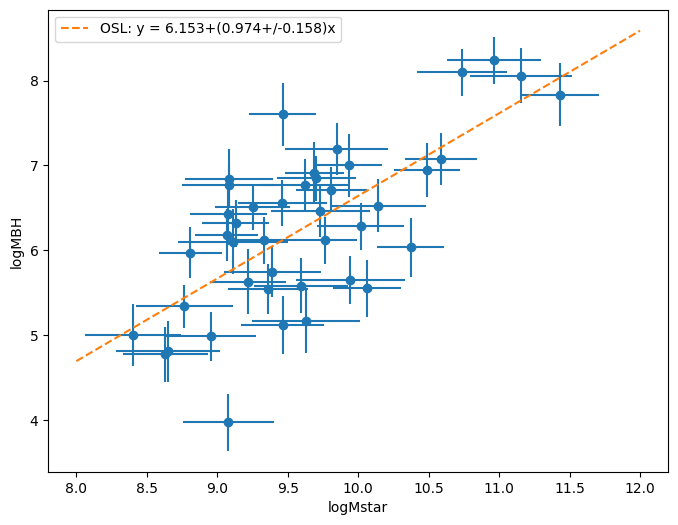

In [1]:
 # Part 1: your work here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as p

NETID = 'asteves2'  # <-- set this
dat = pd.read_csv(f'/Users/andrewsteves/ast457_2026_Fall/labs/04/data/{NETID}.csv')
x, x_err, y, y_err = dat['logMstar'].to_numpy(), dat['err_logMstar'].to_numpy(), dat['logMBH'].to_numpy(), dat['err_logMBH'].to_numpy()

#Design matrix: contains all information about the line aX+b where in the ordinary case all a's and b's are weighted the same
def OSL(x, y):
    A = np.vstack([np.ones_like(x), x - 9.5]).T

    AtA_inv = np.linalg.inv(A.T @ A)
    theta = AtA_inv @ A.T @ y
    resid = y - A @ theta

    N, k = A.shape
    s2 = resid @ resid / (N-k)
    cov = s2 * AtA_inv

    return theta, cov

theta, cov = OSL(x, y)

xx = np.linspace(8, 12, 100)
alpha_OSL = theta[1]
a_stddev_OSL = np.sqrt(cov[1, 1])
beta_OSL = theta[0]

fig= plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr = y_err, xerr = x_err, fmt = 'o')
plt.plot(xx, beta_OSL + (xx - 9.5) * alpha_OSL, label = f'OSL: y = {beta_OSL:.3f}+({alpha_OSL:.3f}+/-{a_stddev_OSL:.3f})x', linestyle = '--')
plt.xlabel('logMstar')
plt.ylabel('logMBH')
plt.legend()

plt.show()

**ANSWER (a few sentences):**

The ordinary least squares regression requires that the noise of a model is Gaussian, the x values are exact, and all points are independent. Because the log values of the stellar mass ratios have an associated uncertainty, they are necessarily not exact so an OSL does not apply here. The data is fit by the line with parameters $\beta$=6.153 and $\alpha$=0.947+-/-0.158. In this case, the x errors have the effect of increasing the scatter of the stars about the OSL line.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

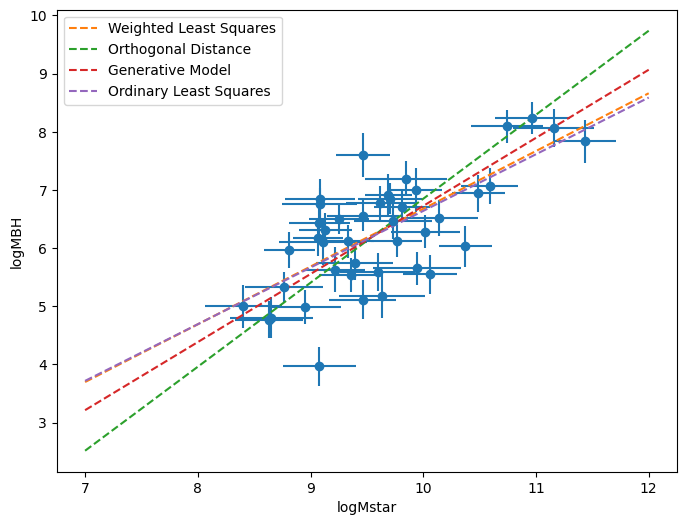

Ordinary Least Squares: alpha = 0.974+/-0.158
Weighted Least Squares Fit: alpha = 0.993+/-0.049, beta = 6.180+/-0.072
Orthogonal Distance Regression: alpha = 1.444+/-0.121, beta = 6.127+/-0.200
Generative Model: alpha = 6.140+/-0.192, beta = 1.170+/-0.110, sig_int: 0.517+/-0.104


In [2]:
# Part 2: your work here
from scipy import odr
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def WSL(x, y):
    A = np.vstack([np.ones_like(x), x - 9.5]).T
    Sigma = np.diag(y_err ** 2)
    Sig_inv = np.linalg.inv(Sigma)

    theta_hat = np.linalg.inv(A.T @ Sig_inv @ A) @ A.T @ Sig_inv @ y
    cov = np.linalg.inv(A.T @ Sig_inv @ A)

    return theta_hat, cov

theta_hat, cov = WSL(x, y)
a_stddev_WLS = np.sqrt(cov[0, 0])
b_stddev_WLS = np.sqrt(cov[1, 1])

def fit(b, x):
    return b[0] + (x - 9.5) * b[1]

def ODR(x, y, sx, sy):
    ord = odr.ODR(odr.RealData(x, y, sx = x_err, sy = y_err), odr.Model(fit), beta0 = theta)
    odr_res = ord.run()

    return odr_res

odr_res = ODR(x, y, sx = x_err, sy = y_err)
beta_odr, alpha_odr = odr_res.beta
a_stddev_odr, b_stddev_odr = odr_res.sd_beta[0], odr_res.sd_beta[1]

def neg2logL(p, x = x, y = y, sx = x_err, sy = y_err):
    alpha, beta, log_sint, mu, log_sig_pop = p
    sint2, tau2 = np.exp(2 * log_sint), np.exp(2 * log_sig_pop)   # these are variances
    s11 = tau2 + sx**2
    s22 = alpha**2 * tau2 + sint2 + sy**2
    s12 = alpha * tau2
    dx, dy = x - mu, y - (alpha * (mu - 9.5) + beta)
    det = s11 * s22 - s12**2
    quad = (s22 * dx**2 - 2 * s12 * dx * dy + s11 * dy**2) / det
    return np.sum(np.log(det) + quad)

def numerical_hessian(f, p, h=1e-4):
    p = np.asarray(p, float); n = p.size; H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n); e_j = np.zeros(n); e_i[i] = h; e_j[j] = h
            H[i, j] = (f(p + e_i + e_j) - f(p + e_i - e_j) - f(p - e_i + e_j) + f(p - e_i - e_j)) / (4 * h * h)
    return H

start = [alpha_OSL, beta_OSL, np.log(0.3), np.mean(x), np.log(np.std(x))]
res = minimize(neg2logL, start, method = 'Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))
p_gen = res.x

hess = numerical_hessian(neg2logL, p_gen)
hess_inv = 2 * np.linalg.inv(hess)
a_stddev_gen, b_stddev_gen = np.sqrt(hess_inv[0, 0]), np.sqrt(hess_inv[1, 1])
logsig_int, logsig_int_stddev = p_gen[2], np.sqrt(hess_inv[2, 2])
sig_int = np.exp(logsig_int)
sig_int_stddev = sig_int * logsig_int_stddev

xx = np.linspace(7, 12, 100)

plt.figure(figsize=(8, 6))
plt.errorbar(x, y, yerr = y_err, xerr = x_err, fmt = 'o')
plt.plot(xx, theta_hat[0] + theta_hat[1] * (xx - 9.5), label = 'Weighted Least Squares', linestyle = '--')
plt.plot(xx, beta_odr + alpha_odr * (xx - 9.5), label = 'Orthogonal Distance', linestyle = '--')
plt.plot(xx, p_gen[1] + p_gen[0] * (xx - 9.5), label = 'Generative Model', linestyle = '--')
plt.plot(xx, beta_OSL + alpha_OSL * (xx - 9.5), label = 'Ordinary Least Squares', linestyle = '--')

plt.xlabel('logMstar')
plt.ylabel('logMBH')

plt.legend()
plt.show()

print(f'Ordinary Least Squares: alpha = {alpha_OSL:.3f}+/-{a_stddev_OSL:.3f}')
print(f'Weighted Least Squares Fit: alpha = {theta_hat[1]:.3f}+/-{a_stddev_WLS:.3f}, beta = {theta_hat[0]:.3f}+/-{b_stddev_WLS:.3f}')
print(f'Orthogonal Distance Regression: alpha = {alpha_odr:.3f}+/-{a_stddev_odr:.3f}, beta = {beta_odr:.3f}+/-{b_stddev_odr:.3f}')
print(f'Generative Model: alpha = {p_gen[1]:.3f}+/-{a_stddev_gen:.3f}, beta = {p_gen[0]:.3f}+/-{b_stddev_gen:.3f}, sig_int: {sig_int:.3f}+/-{sig_int_stddev:.3f}')

**FINAL ANSWER:** $\alpha = $ 6.140 $\pm$ 0.192 , $\beta = $ 1.170 $\pm$ 0.110 , $\sigma_{\rm int} = $ 0.267 $\pm$ 0.107 dex

**Justification and uncertainty method (a short paragraph):**

The ordinary least squares model ignores any uncertainty in the x direction, only accounting for noise in the y direction. This is clearly incorrect because the error in the mass of the stars is known. The wighted least squares also relies on the assumption that the masses of each star are precisely known, which they are not. Orthogonal distance regression does account for uncertainties in both the star and black hole mass measurements, while assuming no intrinsic scatter of the masses. The generative model takes all parameters into account by using the errors of both masses as well as the intrinsic scatters of galaxies. Because of its comprehensive nature, I have chosen the generative model's results.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

To test for closure, a data set can be generated using the truth values from the generative model and refit using the same process. To pass the closure test, the model must be able to return the chosen values within one standard deviation. To test for bias and efficiency, the model fits can be obtained for large numbers of random samples and fit to a distribution where the mean and standard deviation can be obtained. The models should ideally be able to obtain the true $\alpha$ value, with the pull of the bias being described by the $R_x$ value. To ensure closer, over a large number of trials the standard deviation should be close to 68%, and any significant deviations from that value mean that the model is under or over estimating error. To test the sensitivity of the generative model, the values off the standard deviation, sampling distribution, and assuming that $\sigma_{int}$ = 0 will be applied independently. If the model is sufficiently sensitive, then all of these assumptions should provide a worse fit.

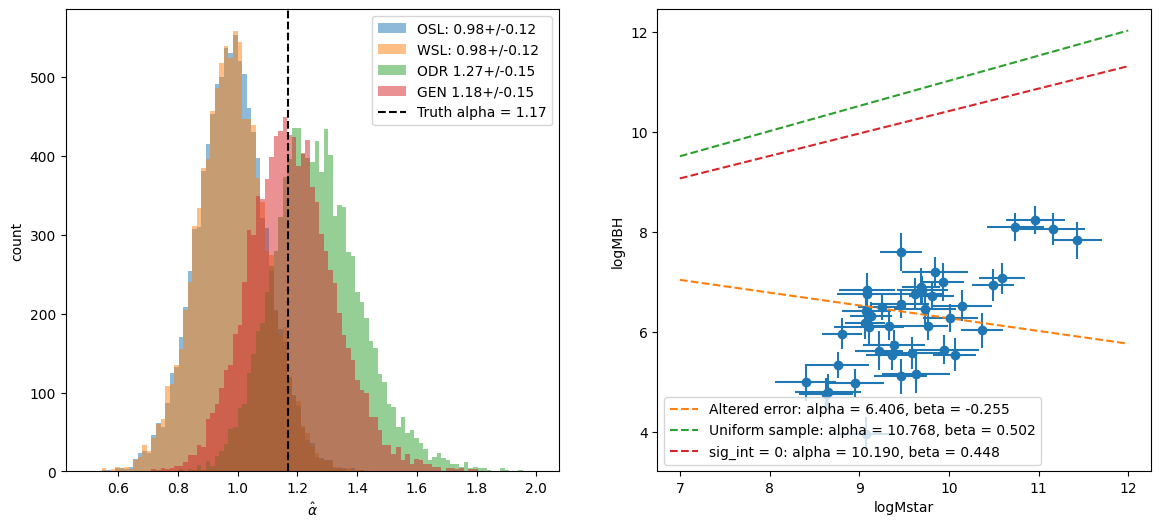

Checks:
Alpha fit: 6.148, alpha_hat - alpha_true = 0.008
gen_a: 68% coverage = 0.677
gen_b: 68% coverage = 0.670
gen_sig_int: 68% coverage = 0.764
Alpha fit (sigma +/- 50%): alpha = -0.255, beta = 6.406
Uniformly sampled Alpha fit: alpha = 0.502, beta = 10.768
sig_int = 0 Alpha fit: alpha = 0.448, beta = 10.190


In [3]:
# Part 3b: execute the plan here
a, b = p_gen[0], p_gen[1]

true = dict(alpha = a, beta = b, sig_int = 0.3, mu = np.mean(x), sig_pop = np.std(x))

N = len(x)
rng = np.random.default_rng(N)
xt = rng.normal(true['mu'], true['sig_pop'], N)
yt = true['alpha'] * (xt - 9.5) + true['beta'] + rng.normal(0, true['sig_int'], N)

x_obs = xt + rng.normal(0, x_err, N)
y_obs = yt + rng.normal(0, y_err, N)

start = [a, b, np.log(0.3), np.mean(x_obs), np.log(np.std(x_obs))]
res = minimize(neg2logL, start, args = (x_obs, y_obs, x_err, y_err), method = 'Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))

p_hat = res.x

rng = np.random.default_rng(N)
results = {'OSL': [], 'WSL': [], 'ODR': [], 'GEN':[]}

for _ in range(10000):
    xt = rng.normal(true['mu'], true['sig_pop'], N)
    yt = true['alpha'] * (xt - 9.5) + true['beta'] + rng.normal(0, true['sig_int'], N)

    x_obs = xt + rng.normal(0, x_err, N)
    y_obs = yt + rng.normal(0, y_err, N)

    theta_osl, cov = OSL(x_obs, y_obs)
    results['OSL'].append(theta_osl[1])

    theta_wsl, cov = WSL(x_obs, y_obs)
    results['WSL'].append(theta_wsl[1])

    theta_odr = ODR(x_obs, y_obs, x_err, y_err)
    results['ODR'].append(theta_odr.beta[1])

    theta_gen = minimize(neg2logL, [theta_osl[1], theta_osl[0], np.log(0.3), np.mean(x_obs), np.log(np.std(x_obs))],
                         args = (x_obs, y_obs, x_err, y_err), method = 'Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))
    results['GEN'].append(theta_gen.x[0])

results_closure = {'gen_a': {'val': [], 'sig': []}, 'gen_b': {'val': [], 'sig': []}, 'gen_sig_int': {'val': [], 'sig': []}}

for _ in range(10000):
    xt = rng.normal(true['mu'], true['sig_pop'], N)
    yt = true['alpha'] * (xt - 9.5) + true['beta'] + rng.normal(0, true['sig_int'], N)

    x_obs = xt + rng.normal(0, x_err, N)
    y_obs = yt + rng.normal(0, y_err, N)

    theta_osl, cov = OSL(x_obs, y_obs)
    res = minimize(neg2logL, [theta_osl[1], theta_osl[0], np.log(0.3), np.mean(x_obs), np.log(np.std(x_obs))],
                         args = (x_obs, y_obs, x_err, y_err), options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))
    p = res.x
    cov = 2 * res.hess_inv

    results_closure['gen_a']['val'].append(p[0])
    results_closure['gen_a']['sig'].append(np.sqrt(cov[0, 0]))
    results_closure['gen_b']['val'].append(p[1])
    results_closure['gen_b']['sig'].append(np.sqrt(cov[1, 1]))

    sint_hat = np.exp(p[2]); sint_sig = sint_hat * np.sqrt(cov[2, 2])
    results_closure['gen_sig_int']['val'].append(sint_hat)
    results_closure['gen_sig_int']['sig'].append(sint_sig)

x_err_sen = 1.5 * x_err

rng = np.random.default_rng(N)
xt_alt_err = rng.normal(true['mu'], true['sig_pop'], N)
yt_alt_err = true['alpha'] * (xt - 9.5) + true['beta'] + rng.normal(0, true['sig_int'], N)

x_obs_alt_err = xt_alt_err + rng.normal(0, x_err_sen, N)
y_obs_alt_err = yt_alt_err + rng.normal(0, y_err, N)

start = [a, b, np.log(0.3), np.mean(x_obs_alt_err), np.log(np.std(y_obs_alt_err))]
res_alt_err = minimize(neg2logL, start, args = (x_obs_alt_err, y_obs_alt_err, x_err_sen, y_err), method = 'Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))

p_hat_alt_err = res_alt_err.x

rng = np.random.default_rng(N)
xt_uni = rng.uniform(0.5, 2, N)
yt_uni = true['alpha'] * (xt - 9.5) + true['beta'] + rng.uniform(0, true['sig_int'], N)

x_obs_uni = xt_uni + rng.uniform(0, x_err, N)
y_obs_uni = yt_uni + rng.uniform(0, y_err, N)

start = [a, b, np.log(0.3), np.mean(x_obs_uni), np.log(np.std(x_obs_uni))]
res_uni = minimize(neg2logL, start, args = (x_obs_uni, y_obs_uni, x_err, y_err), method = 'Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))

p_hat_uni = res_uni.x

rng = np.random.default_rng(N)
xt_sig0 = rng.uniform(0.5, 2, N)
yt_sig0 = true['alpha'] * (xt - 9.5) + true['beta'] + rng.uniform(0, 0, N)

x_obs_sig0 = xt_sig0 + rng.uniform(0, x_err, N)
y_obs_sig0 = yt_sig0 + rng.uniform(0, y_err, N)

start = [a, b, np.log(0.3), np.mean(x_obs_sig0), np.log(np.std(x_obs_sig0))]
res_sig0 = minimize(neg2logL, start, args = (x_obs_sig0, y_obs_sig0, x_err, y_err), method = 'Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))

p_hat_sig0 = res_sig0.x

truth = {'gen_a': true['alpha'], 'gen_b': true['beta'], 'gen_sig_int': true['sig_int']}

bins = np.linspace(0.5, 2, 100)
fig, ax = plt.subplots(ncols = 2, nrows = 1, figsize = (14, 6))

ax[0].hist(results['OSL'], bins = bins, label = f"OSL: {np.mean(results['OSL']):.2f}+/-{np.std(results['OSL']):.2f}", alpha = 0.5)
ax[0].hist(results['WSL'], bins = bins, label = f"WSL: {np.mean(results['WSL']):.2f}+/-{np.std(results['WSL']):.2f}", alpha = 0.5)
ax[0].hist(results['ODR'], bins = bins, label = f"ODR {np.mean(results['ODR']):.2f}+/-{np.std(results['ODR']):.2f}", alpha = 0.5)
ax[0].hist(results['GEN'], bins = bins, label = f"GEN {np.mean(results['GEN']):.2f}+/-{np.std(results['GEN']):.2f}", alpha = 0.5)
ax[0].axvline(true['alpha'], color = 'k', linestyle = '--', label = f'Truth alpha = {true["alpha"]:.2f}')

ax[1].errorbar(x, y, yerr = y_err, xerr = x_err, fmt = 'o')
ax[1].plot(xx, p_hat_alt_err[1] + (xx - 9.5) * p_hat_alt_err[0], label = f'Altered error: alpha = {p_hat_alt_err[1]:.3f}, beta = {p_hat_alt_err[0]:.3f}', linestyle = '--')
ax[1].plot(xx, p_hat_uni[1] + (xx - 9.5) * p_hat_uni[0], label = f'Uniform sample: alpha = {p_hat_uni[1]:.3f}, beta = {p_hat_uni[0]:.3f}', linestyle = '--')
ax[1].plot(xx, p_hat_sig0[1] + (xx - 9.5) * p_hat_sig0[0], label = f'sig_int = 0: alpha = {p_hat_sig0[1]:.3f}, beta = {p_hat_sig0[0]:.3f}', linestyle = '--')

ax[0].set_xlabel(r'$\hat\alpha$')
ax[0].set_ylabel('count')
ax[0].legend()

ax[1].set_xlabel('logMstar')
ax[1].set_ylabel('logMBH')
ax[1].legend()

plt.show()

print('Checks:')
print(f'Alpha fit: {p_hat[1]:.3f}, alpha_hat - alpha_true = {(p_hat[1] - b):.3f}')
for name, d in results_closure.items():
    val, sig = np.array(d['val']), np.array(d['sig'])
    coverage = np.mean(np.abs(val - truth[name]) < sig)
    print(f"{name}: 68% coverage = {coverage:.3f}")
print(f'Alpha fit (sigma +/- 50%): alpha = {p_hat_alt_err[0]:.3f}, beta = {p_hat_alt_err[1]:.3f}')
print(f'Uniformly sampled Alpha fit: alpha = {p_hat_uni[0]:.3f}, beta = {p_hat_uni[1]:.3f}')
print(f'sig_int = 0 Alpha fit: alpha = {p_hat_sig0[0]:.3f}, beta = {p_hat_sig0[1]:.3f}')

**WHAT THE CHECKS FOUND:**

It seems that the generative model has passed the tests well enough to be a believable fit for this dataset. Over a large number of resampling iterations, the model returns the chosen alpha with a negligible difference between the values. Over 10000 MC samples, two of the four models (generative, ODR) return the true slope value within one standard of the population mean. This means that for either model, the alpha value can be trusted to a reasonable degree. Over a large number of iteration, the alpha, beta, and sigma_int values can be recovered to one standard deviation about 70% of the time. From the right-most figure, we can see that changing the values of the parameters or where the distribution used to sample points alters the best fit line significantly.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

Claude was used for aiding in conceptual understanding of problems, and providing information for starting, progressing, and debugging quesitons.